In [19]:
import sys
import pandas as pd
sys.path.append("..")
from utils.market_data import get_candles

In [20]:
from datetime import date

ticker1 = "SBER"
ticker1_api_params = ["stock", "shares", "TQBR"]

ticker2 = "SRM6"
ticker2_api_params = ["futures", "forts", "RFUD"]

start_date = date(2025, 11, 2)
end_date = date(2026, 5, 23)

In [21]:
df1 = get_candles(ticker1, start_date, end_date, engine=ticker1_api_params[0], market=ticker1_api_params[1], board=ticker1_api_params[2], interval=10)
df2 = get_candles(ticker2, start_date, end_date, engine=ticker2_api_params[0], market=ticker2_api_params[1], board=ticker2_api_params[2], interval=10)

print(df1.head(1))
print(df2.head(1))

C:\Users\bakae\OneDrive\Desktop\Quant\Moex-Stat-Arb\notebooks\..\utils\market_data.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, temp_df], ignore_index=True)


Number of deleted duplicates: 5329
Number of deleted duplicates: 1494
                      open  close   high    low    value volume  \
timestamp                                                         
2025-11-03 06:50:00  538.2  538.2  538.2  538.2  41979.6     78   

                                     end  
timestamp                                 
2025-11-03 06:50:00  2025-11-03 06:59:59  
                      open  close   high    low value volume  \
timestamp                                                      
2025-12-22 16:10:00  60666  60666  60666  60666     0      1   

                                     end  
timestamp                                 
2025-12-22 16:10:00  2025-12-22 16:13:01  


In [22]:
df1.sort_values(by="timestamp", inplace=True)
df2.sort_values(by="timestamp", inplace=True)

df = pd.merge_asof(
    df1,
    df2,
    left_on="timestamp",
    right_on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("1m")
)
df.head(1)

,timestamp,open_x,close_x,high_x,low_x,value_x,volume_x,end_x,open_y,close_y,high_y,low_y,value_y,volume_y,end_y
0,2025-11-03 06:50:00,538.2,538.2,538.2,538.2,41979.6,78,2025-11-03 06:59:59,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df = df[["timestamp", "close_x", "close_y"]]
df["spread"] = df["close_y"] - df["close_x"]

Text(0.5, 1.0, 'Spread between TATN and TTM6')

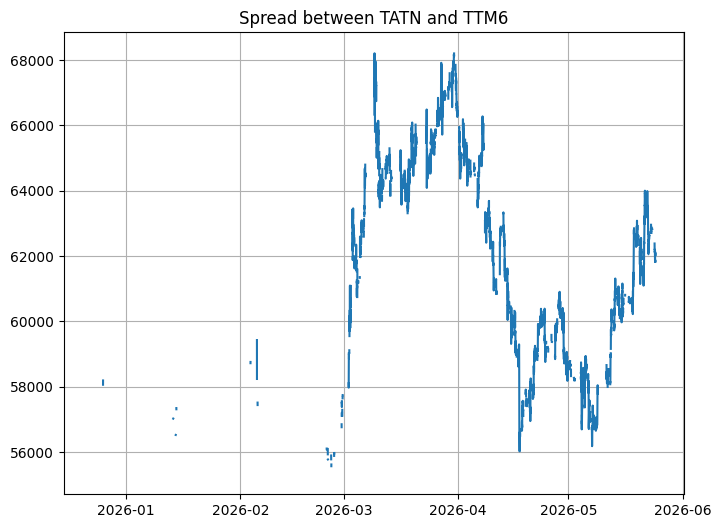

In [24]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(8,6))
plt.plot(df['timestamp'], df['spread'])
plt.grid()
plt.title(f"Spread between {ticker1} and {ticker2}")

In [25]:
window=40
df['rolling_mean'] = df['spread'].rolling(window=window).mean()
df['rolling_std'] = df['spread'].rolling(window=window).std()

df['z_score'] = (df['spread'] - df['rolling_mean'])/df['rolling_std']

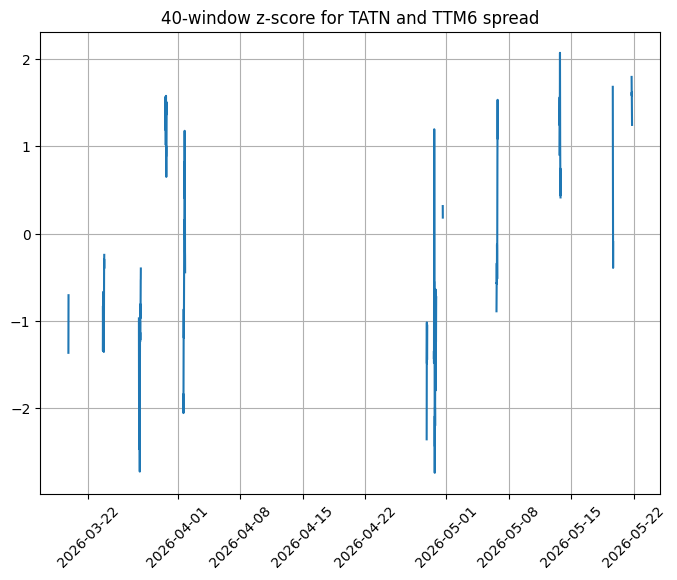

In [26]:
fig = plt.figure(figsize=(8,6))

plt.plot(df['timestamp'], df['z_score'])
plt.xticks(rotation=45)
plt.title(f"{window}-window z-score for {ticker1} and {ticker2} spread")
plt.grid()
plt.show()